In [50]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from keras.models import Sequential
from keras.layers import Dense

Using TensorFlow backend.


In [51]:
np.random.seed(7)

In [52]:
airline_data=pd.read_csv('international-airline-passengers.csv', usecols=[1])

In [53]:
airline_data.head()

,International airline passengers: monthly totals in thousands. Jan 49 ? Dec 60
0,112.0
1,118.0
2,132.0
3,129.0
4,121.0


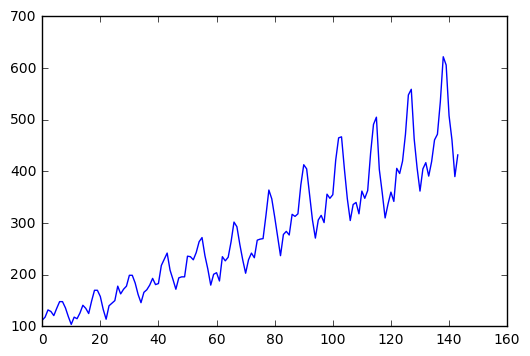

In [54]:
plt.plot(airline_data, c='b')
plt.show()

In [55]:
#load the dataset
dataframe =pd.read_csv('international-airline-passengers.csv', usecols=[1],
                      engine = 'python', skipfooter=3)
dataset = dataframe.values
dataset = dataset.astype('float32')

In [56]:
dataset.shape

(144, 1)

In [57]:
#split into train and test sets
train_size=int(len(dataset)*0.67)
test_size=len(dataset)-train_size
train, test = dataset[0:train_size, :], dataset[train_size:len(dataset),:]
print(len(train), len(test))

96 48


In [58]:
#convert an array of values into a dataset matrix
def create_dataset(dataset, look_back=1):
    dataX, dataY =[],[]
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), 0]
        dataX.append(a)
        dataY.append(dataset[i+look_back, 0])
    return np.array(dataX), np.array(dataY)

In [59]:
#reshape into X=t and Y=t+1
look_back =1
trainX, trainY = create_dataset(train, look_back)
testX, testY = create_dataset(test, look_back)

In [61]:
#fitting the perceptron model
model = Sequential()
model.add(Dense(8, input_dim=look_back, activation = 'relu'))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer = 'adam')
model.fit(trainX, trainY, nb_epoch=200, batch_size=2, verbose=2)

C:\Users\saiva\Miniconda3\lib\site-packages\keras\models.py:848: UserWarning: The `nb_epoch` argument in `fit` has been renamed `epochs`.
  warnings.warn('The `nb_epoch` argument in `fit` '


Epoch 1/200
0s - loss: 92560.9491
Epoch 2/200
0s - loss: 82303.1139
Epoch 3/200
0s - loss: 73039.8451
Epoch 4/200
0s - loss: 64204.7235
Epoch 5/200
0s - loss: 56111.5524
Epoch 6/200
0s - loss: 48392.4826
Epoch 7/200
0s - loss: 41248.3834
Epoch 8/200
0s - loss: 34626.3017
Epoch 9/200
0s - loss: 28641.7187
Epoch 10/200
0s - loss: 23248.4066
Epoch 11/200
0s - loss: 18494.8872
Epoch 12/200
0s - loss: 14391.6306
Epoch 13/200
0s - loss: 10972.0015
Epoch 14/200
0s - loss: 8184.6606
Epoch 15/200
0s - loss: 5958.3078
Epoch 16/200
0s - loss: 4265.2467
Epoch 17/200
0s - loss: 3026.7574
Epoch 18/200
0s - loss: 2143.2303
Epoch 19/200
0s - loss: 1536.3272
Epoch 20/200
0s - loss: 1139.1990
Epoch 21/200
0s - loss: 887.6819
Epoch 22/200
0s - loss: 735.0085
Epoch 23/200
0s - loss: 643.4018
Epoch 24/200
0s - loss: 591.8546
Epoch 25/200
0s - loss: 564.3865
Epoch 26/200
0s - loss: 548.2988
Epoch 27/200
0s - loss: 540.8329
Epoch 28/200
0s - loss: 537.3109
Epoch 29/200
0s - loss: 536.0454
Epoch 30/200
0s - l

In [65]:
train_score=model.evaluate(trainX, trainY, verbose=0)
print('Train Score:%.2f MSE (%.2f RMSE)' % (train_score, math.sqrt(train_score)))
test_score = model.evaluate(testX, testY, verbose=0)
print('Test Score: %.2f MSE (%.2f RMSE)' % (test_score, math.sqrt(test_score)))


Train Score:530.91 MSE (23.04 RMSE)
Test Score: 2352.32 MSE (48.50 RMSE)


## generating predictions for the model 

In [69]:
#generating predictions for the training
train_predict =model.predict(trainX)
test_predict = model.predict(testX)
train_predict.shape

(94, 1)

In [76]:
train_predict_plot =np.empty_like(dataset)
train_predict_plot[:,:] = np.nan
train_predict_plot[look_back: len(train_predict)+look_back, :] =train_predict

test_predict_plot =np.empty_like(dataset)
test_predict_plot[:,:] = np.nan
test_predict_plot[len(train_predict)+(look_back*2)+1: len(dataset)-1, :] = test_predict

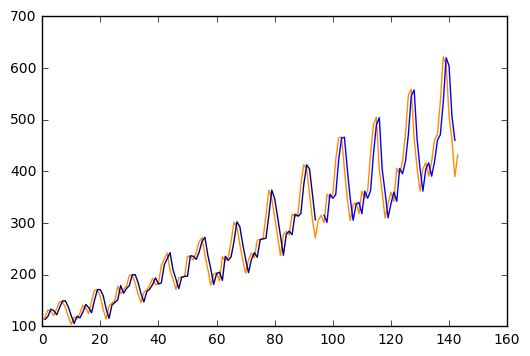

In [78]:
plt.plot(dataset, c='darkorange')
plt.plot(train_predict_plot, c='navy')
plt.plot(test_predict_plot, c = 'blue');